In [6]:
import nltk
from matplotlib import pyplot as plt
from nltk.corpus import stopwords
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
import pandas as pd

from plot_utils import plot_2d

nltk.download('stopwords')
russian_stopwords = stopwords.words("russian")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
def find_optimal_k(X, K: range = range(2, 200), plot_results=True):
    K = list(K)
    inertias = []
    silhouettes = []

    for k in K:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X)
        inertias.append(model.inertia_)
        score = silhouette_score(X, labels)
        silhouettes.append(score)
        print(f"k={k}: inertia={model.inertia_:.0f}, silhouette={score:.3f}")

    # Визуализация
    if plot_results:
        plot_2d(list(K), inertias, "Количество кластеров (k)", "Inertia", "Метод локтя")
        plot_2d(list(K), silhouettes, "Количество кластеров (k)", "Silhouette Score", "Silhouette")

    best_silhouette = max((s for s in silhouettes if not pd.isna(s)), default=None)
    best_k = K[silhouettes.index(best_silhouette)] if best_silhouette is not None else None
    best_inertia = inertias[K.index(best_k)] if best_k is not None else None
    return {
        "best_k": best_k,
        "best_silhouette": best_silhouette,
        "best_inertia": best_inertia,
        "inertias": inertias,
        "silhouettes": silhouettes,
        "k_values": K,
    }


def test_tfidf_configs(texts, vectorizer_params_list, K=range(2, 50)):
    """
    Перебирает разные конфигурации TfidfVectorizer,
    вызывает find_optimal_k() для каждой и рисует
    два итоговых графика: Inertia и Silhouette Score.
    """
    all_results = []

    for params in vectorizer_params_list:
        print(f"\n🔹 TF-IDF параметры: {params}")

        # 1️⃣ Векторизация текста
        vectorizer = TfidfVectorizer(**params)
        X = vectorizer.fit_transform(texts)

        # 2️⃣ Используем твою функцию find_optimal_k
        res = find_optimal_k(X, K, plot_results=False)
        all_results.append({
            "params": params,
            "inertias": res["inertias"],
            "silhouettes": res["silhouettes"],
            "k_values": list(res["k_values"]),
            "best_k": res["best_k"],
            "best_silhouette": res["best_silhouette"]
        })

    # 3️⃣ Общие графики сравнения
    plt.figure(figsize=(12, 5))

    # --- Inertia ---
    plt.subplot(1, 2, 1)
    for r in all_results:
        plt.plot(r["k_values"], r["inertias"], marker='o', label=str(r["params"]))
    plt.title("Inertia для разных параметров TF-IDF")
    plt.xlabel("Количество кластеров (k)")
    plt.ylabel("Inertia")
    plt.legend()
    plt.grid(True)

    # --- Silhouette ---
    plt.subplot(1, 2, 2)
    for r in all_results:
        plt.plot(r["k_values"], r["silhouettes"], marker='o', label=str(r["params"]))
    plt.title("Silhouette Score для разных параметров TF-IDF")
    plt.xlabel("Количество кластеров (k)")
    plt.ylabel("Silhouette Score")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return all_results


In [8]:
df = pd.read_csv('../events/2_struct/2000-2025.csv')

# Пробуем первую попавшуюся модель кластеризации
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=russian_stopwords
)
X = vectorizer.fit_transform(df["event"].str.lower())

k = 186
model = KMeans(n_clusters=k, random_state=42)
df["cluster"] = model.fit_predict(X)

for i in range(k):
    print(f"\n🟢 Кластер {i}")
    examples = df[df["cluster"] == i]["event"].head(10)
    for e in examples:
        print("  -", e)


🟢 Кластер 0
  - В Москве и Мытищах стартовал ежегодный чемпионат мира по хоккею с шайбой. Он продлился до 13 мая.
  - Россия завоевала золото на 72-м чемпионате мира по хоккею с шайбой в канаде.
  - 74-й чемпионат мира по хоккею с шайбой (Германия).
  - В кёльне (германия) состоялся финал 74-го чемпионата мира по хоккею с шайбой. победу одержала сборная чехии.
  - чемпионат мира по хоккею с шайбой (Братислава, Кошице; Словакия). Чемпионом стала сборная Финляндии.
  - Завершился 75-й чемпионат мира по хоккею с шайбой, победу одержала сборная финляндии.
  - чемпионат мира по хоккею с шайбой (Финляндия, Швеция). Победу одержала сборная России.
  - молодёжный чемпионат мира по хоккею c шайбой (Уфа, Россия).
  - 77-й чемпионат мира по хоккею с шайбой (Стокгольм, Швеция и Хельсинки, Финляндия). Сборная Швеции выиграла чемпионат мира в девятый раз.
  - 78-й чемпионат мира по хоккею с шайбой (Минск, Белоруссия) Победу одержала сборная России.

🟢 Кластер 1
  - Арабо-израильский конфликт: Армия

In [9]:
# Находим оптимальное число кластеров у первой попавшейся модели
find_optimal_k(X, range(2, 200))
# По графику делаю вывод, что с увеличением кол-ва кластеров результаты постепенно улучшаются. Локоть не наблюдается.
# Время выполнения: ~9m минут. Лучший результат: k=199: inertia=4495, silhouette=0.042

k=2: inertia=5544, silhouette=0.007
k=3: inertia=5507, silhouette=0.009
k=4: inertia=5473, silhouette=0.011
k=5: inertia=5443, silhouette=0.013
k=6: inertia=5409, silhouette=0.015
k=7: inertia=5396, silhouette=0.015
k=8: inertia=5369, silhouette=0.017
k=9: inertia=5356, silhouette=0.015
k=10: inertia=5337, silhouette=0.014
k=11: inertia=5317, silhouette=0.018
k=12: inertia=5305, silhouette=0.019
k=13: inertia=5309, silhouette=0.015
k=14: inertia=5287, silhouette=0.017
k=15: inertia=5271, silhouette=0.019
k=16: inertia=5266, silhouette=0.021
k=17: inertia=5252, silhouette=0.022
k=18: inertia=5243, silhouette=0.020
k=19: inertia=5233, silhouette=0.020
k=20: inertia=5213, silhouette=0.021
k=21: inertia=5217, silhouette=0.021
k=22: inertia=5204, silhouette=0.021
k=23: inertia=5205, silhouette=0.020
k=24: inertia=5179, silhouette=0.021
k=25: inertia=5170, silhouette=0.021
k=26: inertia=5168, silhouette=0.021
k=27: inertia=5161, silhouette=0.022
k=28: inertia=5150, silhouette=0.023
k=29: ine

{'best_k': 163,
 'best_silhouette': 0.04226056122080725,
 'best_inertia': 4578.409063732633}


🔹 TF-IDF параметры: {'max_features': 1000}
k=2: inertia=5401, silhouette=0.016
k=3: inertia=5340, silhouette=0.019
k=4: inertia=5285, silhouette=0.022
k=5: inertia=5242, silhouette=0.023
k=6: inertia=5172, silhouette=0.028
k=7: inertia=5140, silhouette=0.031
k=8: inertia=5141, silhouette=0.030
k=9: inertia=5073, silhouette=0.031
k=10: inertia=5046, silhouette=0.031
k=11: inertia=5016, silhouette=0.038
k=12: inertia=5018, silhouette=0.036
k=13: inertia=4996, silhouette=0.038
k=14: inertia=4962, silhouette=0.036
k=15: inertia=4934, silhouette=0.039
k=16: inertia=4915, silhouette=0.038
k=17: inertia=4910, silhouette=0.038
k=18: inertia=4881, silhouette=0.041
k=19: inertia=4870, silhouette=0.040
k=20: inertia=4856, silhouette=0.040
k=21: inertia=4836, silhouette=0.041
k=22: inertia=4826, silhouette=0.041
k=23: inertia=4804, silhouette=0.043
k=24: inertia=4793, silhouette=0.043
k=25: inertia=4780, silhouette=0.042
k=26: inertia=4768, silhouette=0.045
k=27: inertia=4768, silhouette=0.042
k=

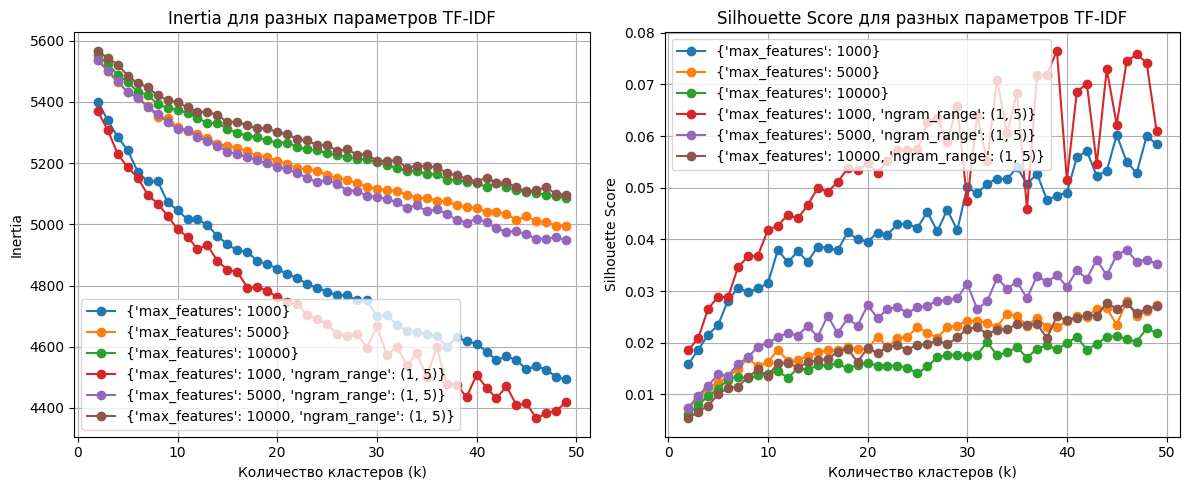

[{'params': {'max_features': 1000},
  'inertias': [5400.710697353179,
   5339.711390731371,
   5285.386836345486,
   5241.760108992335,
   5172.346408321403,
   5140.094762814989,
   5141.258134143236,
   5072.676043810783,
   5045.830853435382,
   5016.026373627001,
   5017.736582665843,
   4996.452290116914,
   4962.414537237944,
   4934.243425668078,
   4914.985234926698,
   4909.897151557586,
   4880.610944731624,
   4869.582527218719,
   4855.652997657331,
   4836.216734274057,
   4825.719756896993,
   4804.068694199468,
   4792.822389027465,
   4780.207994301688,
   4767.766062031178,
   4768.20474542129,
   4751.361575210927,
   4751.157617569546,
   4700.764520691724,
   4703.860512438498,
   4670.642383260035,
   4650.536148446924,
   4649.370889703634,
   4641.80375488799,
   4636.287231284233,
   4599.189285562994,
   4630.3888573199565,
   4617.997082623254,
   4609.656063378023,
   4583.645220193399,
   4556.364486166467,
   4568.133471870559,
   4556.895163346492,
   4525

In [15]:
# Пытаемся определить лучший векторизатор текста путем перебора различных параметров
configs = [
    {"max_features": 1000}, # вариант, хуже дефолтного
    {"max_features": 5000}, # дефолтный вариант
    {"max_features": 10_000}, # улучшенный дефолтный вариант
    {"max_features": 1000, "ngram_range": (1, 5)},
    {"max_features": 5000, "ngram_range": (1, 5)},
    {"max_features": 10000, "ngram_range": (1, 5)},
]

df["clean_event"] = df["event"].str.lower()
results = test_tfidf_configs(df["clean_event"], configs, K=range(2, 50))
results
# Лучший результат показали n_features=1000 с n-граммами (k=48: inertia=4373, silhouette=0.077). Попробуем найти для него подходящее кол-во кластеров
# время выполнения 5m

In [17]:
# мы определили лучший векторизатор, теперь пробуем найти подходящее кол-во кластеров
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 5),
    stop_words=russian_stopwords
)
X = vectorizer.fit_transform(df["event"].str.lower())

find_optimal_k(X, range(2, 200))
# best k=190: inertia=3389, silhouette=0.125. Время выполнения 6m 28s

k=2: inertia=5339, silhouette=0.020
k=3: inertia=5275, silhouette=0.024
k=4: inertia=5220, silhouette=0.027
k=5: inertia=5177, silhouette=0.030
k=6: inertia=5115, silhouette=0.035
k=7: inertia=5109, silhouette=0.031
k=8: inertia=5062, silhouette=0.038
k=9: inertia=5026, silhouette=0.040
k=10: inertia=4971, silhouette=0.043
k=11: inertia=4981, silhouette=0.040
k=12: inertia=4937, silhouette=0.046
k=13: inertia=4913, silhouette=0.043
k=14: inertia=4883, silhouette=0.047
k=15: inertia=4854, silhouette=0.049
k=16: inertia=4820, silhouette=0.051
k=17: inertia=4810, silhouette=0.052
k=18: inertia=4796, silhouette=0.053
k=19: inertia=4782, silhouette=0.050
k=20: inertia=4755, silhouette=0.055
k=21: inertia=4714, silhouette=0.060
k=22: inertia=4730, silhouette=0.054
k=23: inertia=4704, silhouette=0.055
k=24: inertia=4698, silhouette=0.058
k=25: inertia=4706, silhouette=0.054
k=26: inertia=4637, silhouette=0.060
k=27: inertia=4665, silhouette=0.060
k=28: inertia=4628, silhouette=0.061
k=29: ine

{'best_k': 190,
 'best_silhouette': 0.12463220566561815,
 'best_inertia': 3389.09578628117,
 'inertias': [5338.910963282075,
  5274.810821754325,
  5219.933408721127,
  5177.237232003812,
  5115.233894194667,
  5109.206904767555,
  5061.9696853466,
  5025.707311793491,
  4970.843674418938,
  4980.9856959089,
  4937.169445478192,
  4912.813788802037,
  4882.8744652958185,
  4853.88233092812,
  4820.211216166835,
  4810.472966095516,
  4796.21805325425,
  4781.879435605453,
  4754.610525084046,
  4714.467629952163,
  4729.6121828656505,
  4703.545774297924,
  4697.903459325365,
  4705.772901309709,
  4637.016726473706,
  4664.7464154067775,
  4627.569549250017,
  4620.009249247668,
  4576.56974422837,
  4560.4996387436,
  4613.596782831903,
  4609.8830413029145,
  4594.380416746479,
  4577.225521835951,
  4572.245934331023,
  4525.96853096279,
  4468.982099172152,
  4522.378479695348,
  4421.886684436637,
  4494.21186680928,
  4495.075081405752,
  4457.801697047479,
  4483.20521275261,
 

In [18]:
# пробуем лучшую модель в действии
k = 190
model = KMeans(n_clusters=k, random_state=42)
df["cluster"] = model.fit_predict(X)

for i in range(k):
    print(f"\n🟢 Кластер {i}")
    examples = df[df["cluster"] == i]["event"].head(10)
    for e in examples:
        print("  -", e)


🟢 Кластер 0
  - В Москве и Мытищах стартовал ежегодный чемпионат мира по хоккею с шайбой. Он продлился до 13 мая.
  - Россия завоевала золото на 72-м чемпионате мира по хоккею с шайбой в канаде.
  - 74-й чемпионат мира по хоккею с шайбой (Германия).
  - чемпионат мира по хоккею с шайбой (Братислава, Кошице; Словакия). Чемпионом стала сборная Финляндии.
  - 32-й чемпионат мира по хоккею с мячом (Алма-Ата, Казахстан).
  - молодёжный чемпионат мира по хоккею c шайбой (Уфа, Россия).
  - 77-й чемпионат мира по хоккею с шайбой (Стокгольм, Швеция и Хельсинки, Финляндия). Сборная Швеции выиграла чемпионат мира в девятый раз.
  - чемпионат мира по хоккею на траве среди мужчин в Гааге (Нидерланды), чемпионам стали хоккеисты Австралии.
  - чемпионат мира по хоккею с шайбой (Москва, Санкт-Петербург, Россия). Чемпионом мира стала сборная Канады.
  - Кубок мира по хоккею с шайбой (Торонто, Канада).

🟢 Кластер 1
  - Вступила в должность Президента Кыргызской Республики переходного периода Роза Отунб